# The bitcoin ETF that pays a toll every month 🎢
### BITO vs actual bitcoin — where the missing 20 percentage points went, in plain English

![Signal: Real](https://img.shields.io/badge/Signal-Real-2ea44f?style=flat-square)
![Tradability: Fragile](https://img.shields.io/badge/Tradability-Fragile-dab617?style=flat-square)
![Reason_to_survive%3F: Busted](https://img.shields.io/badge/Reason_to_survive%3F-Busted-8b949e?style=flat-square)

In October 2021 the US finally got a bitcoin ETF — with an asterisk. **BITO** wasn't allowed to hold bitcoin. It holds **futures**: contracts to buy bitcoin *next month*, listed on a Chicago exchange. Every month those contracts expire, and the fund sells them and buys the next month's batch. That monthly shuffle is called **the roll**.

The folklore says the roll is a **toll booth**: next month's bitcoin usually costs a little *more* than today's (a premium called **contango**), the fund keeps buying at a premium that then melts away, and the holder pays for it — forever.

Since January 2024 there's a perfect way to check: **IBIT** and its siblings hold *actual* bitcoin. Same animal, no futures, no roll. We race all three: BITO, spot bitcoin, and IBIT — counting **every distribution BITO ever paid** (that part matters, you'll see).

> 📓 Want the *t*-stats, the roll-window attribution and the borrow math? See **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)**. Every chart is drawn by the code beside it; house style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root (quantlab)
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from bito_roll_drag import data, strategy as st

HAVE_REAL = data.have_real()
F = data.load_real() if HAVE_REAL else None
print("real tape cached:", HAVE_REAL,
      "| rows:", (0 if F is None else len(F)),
      "| window:", ("-" if F is None else f"{F.index.min().date()} -> {F.index.max().date()}"))

# frozen headline numbers (mirror of docs/results.md)
R = {'start': '2021-10-20', 'end': '2026-06-30', 'asof': '2026-06-30', 'years': 4.69, 'n_days': 1176, 'n_months': 56, 'fingerprint': '48e3e370f939', 'spot_drag_ann': -4.25, 'spot_gap_bps_day': -1.69, 'spot_hac_t': -1.67, 'spot_tr_bito': -31.45, 'spot_tr_spot': -11.26, 'spot_shortfall_pp': -20.18, 'wealth_ratio': 0.773, 'mo_gap_bps': -34.49, 'mo_hac_t': -2.32, 'mo_neg_share': 69.6, 'beta_ibit': 1.003, 'beta_spot': 0.947, 'ibit_start': '2024-01-11', 'ibit_days': 617, 'ibit_years': 2.47, 'ibit_drag_ann': -5.14, 'ibit_gap_bps_day': -2.04, 'ibit_hac_t': -7.68, 'ibit_hac_t_lag5': -7.22, 'ibit_hac_t_lag63': -7.27, 'ibit_tr_bito': 9.99, 'ibit_tr_ibit': 25.01, 'ibit_shortfall_pp': -15.02, 'ibit_wealth_ratio': 0.88, 'ctrl_ibit_spot_ann': 0.28, 'ctrl_ibit_spot_t': 0.1, 'fee_bito': 0.95, 'fee_ibit': 0.25, 'fee_gap': 0.7, 'carry_beyond_fees': 4.44, 'roll': [('vs spot', -4.14, 285, -0.91, 891, -0.33, 24.2, 54.6), ('vs IBIT', -2.84, 150, -1.78, 467, -0.87, 24.3, 33.6)], 'contango_share': 58.5, 'median_basis_bps': 19.1, 'mean_days_to_exp': 13.9, 'ann_basis_median': 4.9, 'ann_basis_2022': -4.72, 'ann_basis_2426': 7.16, 'years_tbl': [(2021, -163.2, 2, -3.24), (2022, 33.3, 12, 3.63), (2023, -56.4, 12, -6.6), (2024, -56.9, 12, -6.78), (2025, -43.7, 12, -5.14), (2026, -20.0, 6, -1.2)], 'regime_2022': 33.3, 'regime_2023p': -47.7, 'regime_welch_t': 0.98, 'daily_split_contango': -6.16, 'daily_split_backward': -3.35, 'daily_split_t': -1.09, 'spread': [(0.0, 5.14, 4.9, 7.34, 2.55), (2.0, 5.14, 2.9, 4.34, 1.51), (5.0, 5.14, -0.1, -0.16, -0.05)], 'spread_vol': 1.92, 'spread_worst_day': -0.56, 'syn': [(0.0, 0.22, 0.7, 0.2), (-10.95, -10.42, -32.55, 0.11)]}


real tape cached: True | rows: 1177 | window: 2021-10-20 -> 2026-06-30


## The answer first

| Question | Answer |
|---|---|
| Does BITO lag actual bitcoin? | **Yes.** Since inception a dollar in BITO is worth about **77 cents** of the spot-bitcoin dollar — **20 points** of total return went missing in 4.7 years. |
| Is it luck, or a toll? | A toll. Against the spot ETF (same closing bell, cleanest possible ruler) BITO loses **5.1% per year** — and the quants' test says that's about as far from luck as it gets (*t* = -7.7). |
| Is it the fee? | Only partly. Fees explain **0.7pt**; the other **~4.4%/yr** is the futures premium melting, month after month. |
| Is the toll booth at the roll? | **No — that's the twist.** The toll accrues a little *every day* as the premium melts; the roll week itself shows no special bleed. |
| Did it ever flip? | **Yes: 2022.** In the bear market the premium inverted and BITO actually *beat* spot by ~3.6pt that year. Contango giveth back, occasionally. |
| Any reason to hold BITO today? | For bitcoin *exposure*, none we can find: same risk (beta ≈ 1.00 on IBIT), 5.1%/yr lighter. The famous "monthly income" is your own money handed back. |

## Act I — three ways to buy the same coin

Below: a dollar into **spot bitcoin**, into **BITO** (with every monthly distribution reinvested — the fair way to count), and into **IBIT** from the day it listed. Same underlying, one of them pays a toll.

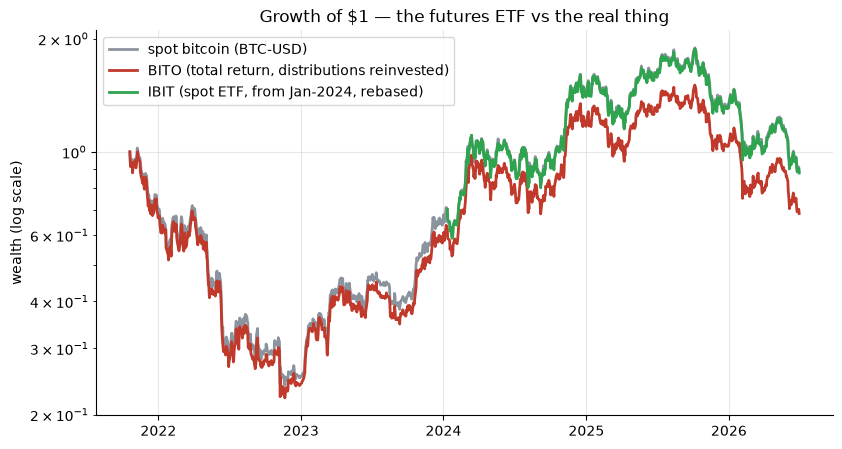

final: spot 0.887  BITO 0.686  -> BITO/spot wealth ratio 0.773


In [2]:
if HAVE_REAL:
    fig, ax = plt.subplots()
    w = F[['spot', 'bito']] / F[['spot', 'bito']].iloc[0]
    ax.plot(w.index, w['spot'], color=GREY, lw=2, label='spot bitcoin (BTC-USD)')
    ax.plot(w.index, w['bito'], color=RED, lw=2, label='BITO (total return, distributions reinvested)')
    ib = F['ibit'].dropna(); ib = ib / ib.iloc[0] * w['spot'].loc[ib.index[0]]
    ax.plot(ib.index, ib, color=GREEN, lw=2, label='IBIT (spot ETF, from Jan-2024, rebased)')
    ax.set_title('Growth of $1 — the futures ETF vs the real thing')
    ax.set_ylabel('wealth (log scale)'); ax.set_yscale('log'); ax.legend()
    plt.show()
    print(f"final: spot {w['spot'].iloc[-1]:.3f}  BITO {w['bito'].iloc[-1]:.3f}  "
          f"-> BITO/spot wealth ratio {w['bito'].iloc[-1]/w['spot'].iloc[-1]:.3f}")
else:
    print('cache missing - frozen numbers:', R['spot_tr_bito'], '% BITO vs', R['spot_tr_spot'], '% spot')

Same coin, different vehicles. Spot bitcoin finished the window at **-11.3%**; BITO — *with every distribution reinvested* — at **-31.4%**. The gap (**-20.2 points**) is the toll.

> ⚠️ **About those distributions.** BITO is famous for fat monthly payouts. They are not extra return — they're the fund handing your own gains back (and its price drops by the same amount). Anyone comparing BITO's *price* chart to bitcoin is overstating the toll enormously; we reinvest everything and the toll is still there.

## Act II — watch the toll accrue

Divide BITO's wealth by spot's wealth: flat means fair tracking, downhill means the toll is running. One year stands out.

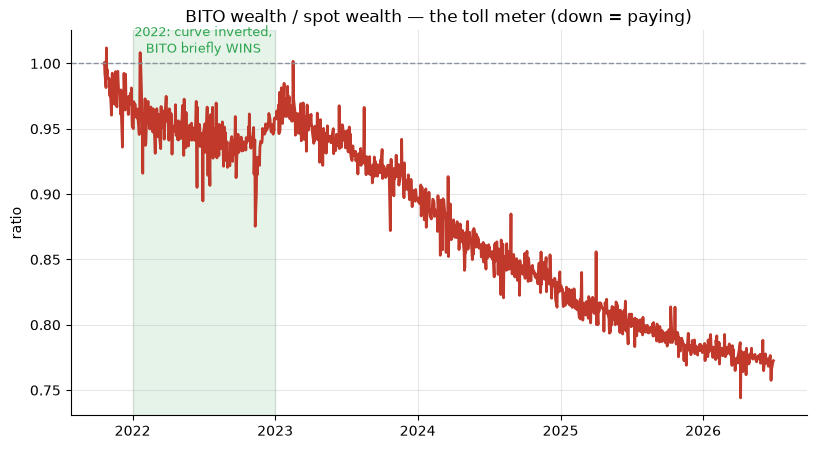

In [3]:
if HAVE_REAL:
    w = F[['spot', 'bito']] / F[['spot', 'bito']].iloc[0]
    ratio = w['bito'] / w['spot']
    fig, ax = plt.subplots()
    ax.plot(ratio.index, ratio, color=RED, lw=2)
    ax.axhline(1.0, color=GREY, ls='--', lw=1)
    ax.axvspan(pd.Timestamp('2022-01-01'), pd.Timestamp('2022-12-31'), color=GREEN, alpha=.12)
    ax.annotate('2022: curve inverted,\nBITO briefly WINS', xy=(pd.Timestamp('2022-07-01'), ratio.loc['2022'].max()),
                ha='center', fontsize=9, color=GREEN)
    ax.set_title('BITO wealth / spot wealth — the toll meter (down = paying)')
    ax.set_ylabel('ratio')
    plt.show()
else:
    print('cache missing - frozen wealth ratio:', R['wealth_ratio'])

The slope is the story. Downhill in 2021, 2023, 2024, 2025, 2026 — every year the futures curve sat in **contango** (next month more expensive than today). And one green stretch: **2022**, the bear market, when fear inverted the curve (**backwardation** — next month *cheaper*) and the roll briefly *paid* BITO holders about **+3.6 points**. The toll is not a law of nature; it's the price of the crowd usually leaning bullish.

| year | toll (per month) | over the year |
|---|--:|--:|
| 2021 | -163 bps | -3.24 pp |
| 2022 | +33 bps | +3.63 pp |
| 2023 | -56 bps | -6.60 pp |
| 2024 | -57 bps | -6.78 pp |
| 2025 | -44 bps | -5.14 pp |
| 2026 | -20 bps | -1.20 pp |

> 🔬 **For the quants:** the monthly toll vs spot averages **-34 bps/month** (HAC *t* = -2.32, 70% of months negative); the matched-close race vs IBIT reads **-5.1%/yr at *t* = -7.7**.

## Act III — the twist: the toll booth isn't where you think

"Pays a toll every month it **rolls**" — so the damage should show up in roll week, right? We flagged the five trading days into each futures expiry (last Friday of the month) and compared the bleed inside vs outside that window.

Inside: **-2.8 bps/day**. Outside: **-1.8 bps/day** (vs IBIT). Statistically indistinguishable (*t* ≈ -0.9).

That's not a failed test — it's the mechanism showing its true face. The fund buys next month's bitcoin at a premium, and that premium **melts a little every single day** as the contract drifts toward reality. The roll itself just resets the meter. The folklore is right about the *size* of the toll and wrong about the *where*.

## Act IV — so… why does BITO still exist?

In 2021, BITO was the only game in town — US investors couldn't buy a spot bitcoin fund at any price, and BITO gathered a billion dollars in two days. Fair enough.

Since **January 2024** the spot ETFs exist. Same exposure (the quants measure beta **1.00** — identical), **5.1%/yr cheaper** in realized returns. The classic defenses:

- **"But the monthly income!"** — it's your own capital, repackaged. We reinvested every cent of it and BITO *still* lost by 15 points in 2½ years.
- **"But options!"** — was true; IBIT options listed in **Nov-2024** and are now the deeper market.
- **"But my retirement account!"** — spot ETFs sit in IRAs just fine now.

What's left is habit and habitat. For bitcoin *exposure*, the tape finds **no reason** — stamped **Busted** on the grey axis.

---

## The verdict

**Real** — the toll exists and it's decisive: **-5.1%/yr** against the spot ETF (*t* = -7.7), **77 cents on the dollar** since inception vs spot. **Fragile** as a trade — shorting BITO against IBIT nets a thin ~3%/yr that dies if borrow gets expensive, and the toll itself flipped sign in 2022. And **Busted** on the myth that BITO still earns its keep.

*Full numbers: [docs/results.md](../docs/results.md) · stats: [02_for_the_quants.ipynb](02_for_the_quants.ipynb) · siblings in the mechanical-decay family: [61-slow-burn](../../61-slow-burn/), [100-melting-ice](../../100-melting-ice/), [375-vxx-roll-decay](../../375-vxx-roll-decay/). Research & education, not investment advice.*